# Ensemble learning

L'ensemble learning est une technique de machine learning ou l'on va entrainer plusieurs machine pour ensuite considérer l'ensemble de leurs prédictions.

Il existe trois grandes méthode (le bagging, le boosting et le stacking) et les algorithmes qui se basent sur ces méthodes font parties des plus performantes en machine learning. 

Nous allons commencer par nous intéresser au principe sur lequel se base l'ensemble learning.

## Wisdom of the crowd

Ici ce qui va nous intéresser c'est d'utiliser plusieurs estimateurs pour faire des prédictions :

![caption](EnsembleLearning_01.png)

Ce que l'on peut constater c'est que nos modèles n'ont pas fait les même erreurs au même endroit, on peut donc regarder quels sont les prédictions les plus probable en regardant la prédiction majoritaire :

![caption](EnsembleLearning_02.png)

Ici on peut voir que l'on est passé de trois estimateurs ayant 70% de prédictions correctes à 90 % de prédictions correctes.

C'est ce que l'on appel Wisdom of the crowd. L'idée est simple, une foule d'individu ayant une certaine connaissance d'un sujet aura plus souvent raison qu'un individu seul.

On peut aller très loin avec cette technique, on pourrais regrouper par exemple un ensemble d'estimator ayant en moyenne des scores à peine plus élevé que 50%, et obtenir un score final de 99% de prédictions correctes.

C'est ce que l'on appel la lois des grands nombre :
- Plus le nombre d'individus augmente dans la foule, plus la performance de la majorité s'approche des 100% de bonnes réponses.

![caption](EnsembleLearning_03.png)

Pour que tout celà fonctionne il faut que la foule respecte deux critères important : 
- Il faut que les modèles dans la foule aient au moins 50% de performance (si non on aura l'effet inverse)
- Il faut que notre foule présente un minimum de diversité (si tous nos modèles donnes tous les même réponse, alors les défauts des uns ne peuvent pas être corrigé par les autres).

Et pour faire celà nous allons avoir trois grandes techniques :

## Bagging

Ici l'idée est de créer plusieurs copie d'un même modèle mais de les entrainer sur des parties différentes sélectionnée aléatoirement de notre dataset.

![caption](EnsembleLearning_04.png)

Pour avoir de la diversité nous allons utiliser une technique appellé bootstrapping qui va replacer nos donnés dans le dataset avant de refaire un échantillonage aléatoire. De cette manière nous aurons trois modèle diversifié car ils n'ont pas été entrainer avec les même données mais ils vont tout de même partager une partie de leurs connaissances communes. Celà permet d'éviter que toutes les données d'une valeur de notre target soit connues que d'un seul de nos modèles.

Une fois nos prédictions faites sur tous nos modèles nous pouvons regrouper les prédictions de ceux-ci pour obtenir notre prédiction.

L'algorithm de bagging la plus connue est le RandomForest (un ensemble d'arbre de décision regroupé ensemble ayant été entrainer sur des partie aléatoire de notre dataset). Ici les modèles sont en overfitting, en rassemblant les prédictions celà nous permet donc de réduire la variance de la foule.

## Boosting

Ici le but est d'entrainer plusieurs modèles faibles qui vont chacun s'entrainer à reconnaitre les erreurs de leur prédescensseur.

![caption](EnsembleLearning.webp)

On obtient donc un ensemble de modèle complémentaire qui vont se renforcer les uns les autres.

Nous avons deux grands algorithm pour faire du boosting :
- AdaBoost
- Grandiant Boosting

Donc contrairement au bagging ou nous étions avec un cas de modèle étant tous en overfitting, ici nous avons un ensemble de modèle qui sont en underfitting. Donc mettre les modèles les uns après les autres permet de réduire le biais de la foule.

## Stacking

Ici on fera quelque chose de similaire au bagging, mais au lieu de rassembler les prédictions de chaque modèle et prendre la prédiction majoritaire, nous allons entrainer un nouvel estimateur qui apprendra à prédire les résultats en fonction des prédictions des estimateurs le précédent.

![caption](EnsembleLearning_05.png)

## Le module sklearn.ensemble

Dans ce module nous allons trouver plusieurs class nous permettant de faire de l'ensemble learning :
- Voting Estimator (VotingCLassifier/VotingRegressor) : Ce sont les implémentations les plus simple. Ici on va juste regrouper des estimator pour ensuite regarder les prédictions majoritaires.
- Bagging Estimator (Bagging/Bagging/RandomForest/RandomForest/IsolationForest/ExtraTrees). La technique la plus populaire est le RandomForest, c'est celui sur lequel nous allons nous attardé plus tard.
- Boosting Estimator (AdaBoost/GradientBoos/HistGradiantBoost) : ce sont les estimator de boosting. Les plus populaire sont l'AdaBoost et le GradiantBoosting.
- Stacking Estimator (StackingClassifier/StackingRegressor) : ces deux nouveau estimator de stacking nécéssitent la mise à jours 0.22



In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [394]:
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import SGDClassifier
from sklearn.datasets import load_wine, make_blobs
from sklearn.model_selection import train_test_split

In [395]:
def plot_decision_boundary(clf, X, y, axes=[-1.5, 2.45, -1, 1.5], alpha=0.5, contour=True):
    
    h = .02
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    
    Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=.5)
    
    plt.scatter(X[:,0], X[:,1], c=y, alpha=0.8, edgecolors='k')

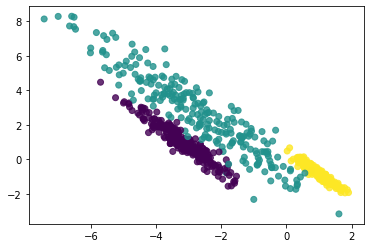

In [396]:
X, y = make_blobs(n_samples=700,
                             cluster_std=[1.0, 2.5, 0.5],
                             random_state=170)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
X = np.array((X_aniso))

plt.scatter(X[:,0], X[:,1], c=y, alpha=0.8)

In [457]:
Xtr, Xts, ytr, yts = train_test_split(X, y, test_size=0.3, random_state=0)

## VOTING

Ici on va d'abord définir les modèles se trouvant dans notre foule.

Ensuite on va passer tous ces estimator à notre VotingClassifier.

In [458]:
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

On va ensuite créer nos estimator, puis on va les passer à notre VotingClassifier. Ceux-ci devront être passé dans des tupple, la première partie du tupple sera le nom que l'on donnera à notre estimator, et la seconde l'estimator lui même.

Nous avons enfin la technique de vote (voting) qui doit être passée : 
- Pour les classifier nous avons deux technique hard et soft :
    - hard voting Ici on fera en fonction des prédicitons [1, 1, 0] ici la classe sera la classe 1
    - soft voting ici on va le faire en fonction des probabilités [[70, 30], [60, 40], [10, 90]] 70 + 60 + 10 = 130 | 30 + 40 + 90 = 160 c'est donc la classe 2 qui l'emporte.
- Pour les regressor nous aurons la technique de moyenne, on fera donc la moyenne des prédictions, ce qui semble normal pour un problème de regression.

Quand utiliser le mode hard ou le mode soft?
Le mode soft a tendance à donner de meilleurs résultats quand les models sont bien calibrer, il est donc préférable de l'utiliser quand c'est possible.

In [474]:
model1 = SGDClassifier(random_state=1)
model2 = SGDClassifier(random_state=5)
model3 = DecisionTreeClassifier(random_state=0)
model4 = DecisionTreeClassifier(random_state=10)
model5 = KNeighborsClassifier(n_neighbors=2)
model6 = KNeighborsClassifier(n_neighbors=1)

model7 = VotingClassifier([('SGD1', model1),
                            ('SGD2', model2),
                            ('Tree1', model3),
                            ('Tree2', model4),
                            ('KNN1', model5),
                            ('KNN2', model6)],
                          voting='hard')

for model in (model1, model2, model3, model4, model5, model6, model7):
    model.fit(Xtr, ytr)
    print(model.__class__.__name__, model.score(Xts, yts))

SGDClassifier 0.8904761904761904
SGDClassifier 0.9809523809523809
DecisionTreeClassifier 0.9714285714285714
DecisionTreeClassifier 0.9714285714285714
KNeighborsClassifier 0.9619047619047619
KNeighborsClassifier 0.9761904761904762
VotingClassifier 0.9809523809523809


En général le VotingClassifier n'est pas très éfficace, car il est difficile de respecter le critère de diversité du Wisdom of the crowd.

Car nos modèles sont certe tous performant mais ils vont souvent être d'accord entre eux, et il y a donc une perte au niveau de la diversité.

## Bagging

In [460]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

Pour le BaggingClassifier, on va lui préciser l'estimateur que l'on désire, ainsi que le nombre d'estimateurs.

In [461]:
model = BaggingClassifier(base_estimator=KNeighborsClassifier(),
                         n_estimators=100)

model.fit(Xtr, ytr)
model.score(Xts, yts)

0.9761904761904762

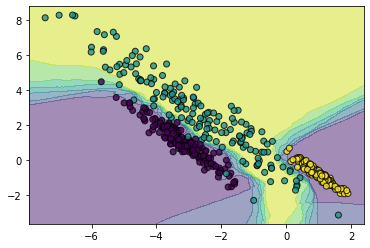

In [462]:
plot_decision_boundary(model, Xtr, ytr)

Pour la random forest, on ne précise que le nombre d'estimateur car il utilisera les arbres de décision.

In [463]:
model = RandomForestClassifier(n_estimators=100)

model.fit(Xtr, ytr)
model.score(Xts, yts)

0.9857142857142858

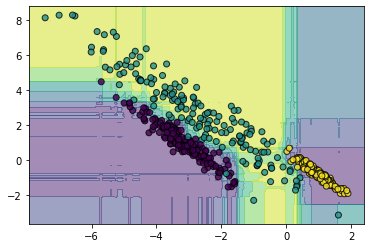

In [464]:
plot_decision_boundary(model, Xtr, ytr)

## Boosting

Ici autant pour l'AdaBoost et le GradiantBoosting nous ne devons que préciser le nombre d'estimator.

AdaBoost utilise des arbres de décision de base mais on peut lui choisir d'autres type d'estimator.

Ici on peut encore une fois utiliser une GridSearchCV pour obtenir les meilleurs résultats.

In [465]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [475]:
model = GradientBoostingClassifier(n_estimators=100)


model.fit(Xtr, ytr)
model.score(Xts, yts)

0.9666666666666667

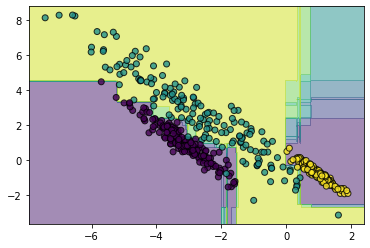

In [476]:
plot_decision_boundary(model, Xtr, ytr)

## Stacking

Le Stacking fonctionne de manière similaire au VotingClassifier.

In [477]:
from sklearn.ensemble import StackingClassifier

In [482]:

model = StackingClassifier([('SGD1', model1),
                            ('SGD2', model2),
                            ('Tree1', model3),
                            ('Tree2', model4),
                            ('KNN1', model5),
                            ('KNN2', model6)],
                             final_estimator=KNeighborsClassifier())

model.fit(Xtr, ytr)
model.score(Xts, yts)

0.9761904761904762

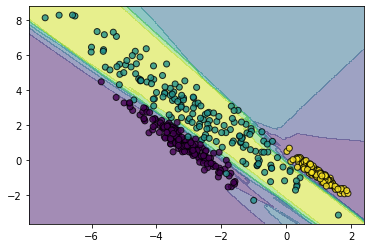

In [483]:
plot_decision_boundary(model, Xtr, ytr)

Quand utiliser quel type d'ensemble ??

On utilisera le bagging quand nos modèles tendent à faire de l'over-fitting.

On utilisera le boosting quand nos modèles tendent à faire de l'under-fitting.

Le stacking quand à lui sera très fort dans le cas ou l'on a passer beaucoup de temps à entrainer chaque modèle individuellement (done une grande foret, avec un réseau de neurones, et un sgdclassifier ayant travaillé des millions d'itérations, ...). Le stacking peut donc être très éfficace mais c'est de loin la plus lente des techniques vue dans ce cours.